# 🧠 Stateful Conversational Agents with Memory & Summarization Middleware

Welcome to the **Stateful Agents & Memory Management** guide! This notebook demonstrates how to build long-running conversational agents that maintain multi-turn context while efficiently managing token usage via **LangChain Summarization Middleware** and **LangGraph Checkpointing**.

---

### 🧠 Key Concepts & Objectives

In production conversational AI applications, managing message history is vital:
- **Stateful Checkpointing (`InMemorySaver`)**: Persists conversation history across independent invocations using a unique `thread_id` session identifier.
- **Context Summarization (`SummarizationMiddleware`)**: Prevents context-window overflow and reduces token costs by automatically compressing older conversation turns when token limits are reached.
- **Dynamic Context Injection**: Injecting domain-specific web data (via `WebBaseLoader`) into the agent's context stream.
- **Multi-Turn Reasoning**: Answering follow-up questions, resolving references (e.g., *"this scale"*, *"dominant chord"*), and leveraging persisted history.

### 📦 Prerequisites
- `langchain`, `langchain-groq`, `langgraph`, `beautifulsoup4`, `python-dotenv`

## 🔑 Step 1: Environment Setup & Dual Model Configuration

Configure the environment and instantiate two specialized Groq LLMs:
1. **Primary Agent Model**: `openai/gpt-oss-20b` (for conversational reasoning and domain Q&A).
2. **Summarizer Model**: `qwen/qwen3.6-27b` (dedicated model used by the middleware to compress conversation history).

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_community.document_loaders import WebBaseLoader
from langchain_groq import ChatGroq
import requests
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage
)
import os
from dotenv import load_dotenv

load_dotenv()

groq_key = os.environ["GROQ_API_KEY"]
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')
W_API_KEY = os.getenv('WEATHER_API_KEY')

llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=groq_key)
summariser = ChatGroq(model="qwen/qwen3.6-27b", groq_api_key=groq_key)

## 🌐 Step 2: Dynamic Web Context Extractor (`WebBaseLoader`)

Define a helper function `web_extractor(url)` using BeautifulSoup and `WebBaseLoader` to scrape and clean web content for dynamic context injection.

In [11]:
import bs4

def web_extractor(url: str):

    web_load = WebBaseLoader(web_path=url, 
                            bs_kwargs=dict(parse_only=bs4.SoupStrainer(),
                            ))
    web_data = web_load.load()
    return web_data[0].page_content

## 🏗️ Step 3: Create Stateful Agent with Summarization Middleware

Initialize the agent with:
- **System Prompt**: Enforces structured answers, context awareness, and conversational reference tracking.
- **`SummarizationMiddleware`**:
  - `trigger=("tokens", 4000)`: Automatically triggers summarization when total token count exceeds 4000.
  - `keep=("tokens", 800)`: Retains the most recent 800 tokens uncompressed to preserve immediate conversational context.
- **`checkpointer=InMemorySaver()`**: Stores conversational state in memory keyed by thread ID.

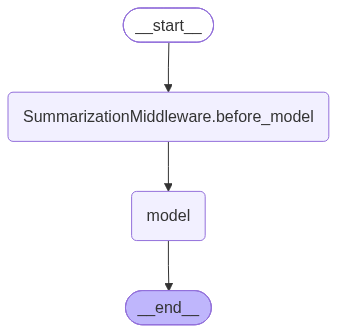

In [12]:
agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="""
        You are a helpful question-answering assistant.

        The user will provide a context/source at the beginning of the conversation.
        Treat this context as the primary source of information for the conversation.

        Use the provided context when answering the user's questions, including follow-up
        questions that refer to information discussed earlier.

        Maintain awareness of the conversation history and use it to understand
        references such as "this", "that", "it", or previous topics.

        If the context does not contain enough information to answer a question,
        you may use your general knowledge when appropriate, but make it clear when
        the answer goes beyond the provided context.

        Answer clearly and elaboratively and in a structured manner.
    """,
    middleware=[
        SummarizationMiddleware(
            model=summariser,
            trigger=("tokens", 4000),
            keep=("tokens", 800)
        )
    ],
    checkpointer=InMemorySaver()
)

agent

## 🧵 Step 4: Configure Thread / Session Identifier

Define a thread configuration dictionary (`thread_id: 'chat_b'`) to maintain conversation continuity across consecutive turns.

In [13]:
config = {"configurable": {
    "thread_id": "chat_b"
}}

## 💬 Step 5: Turn 1 — Initialize Conversation with Web Context

Send the initial user query along with scraped Wikipedia context (C Major scale) injected as a `SystemMessage`.

In [14]:
response = agent.invoke({
    "messages": [
        HumanMessage(content="What is the 3rd note from this given scale"),
        SystemMessage(content=web_extractor(url="https://en.wikipedia.org/wiki/C_major"))
    ]
}, config=config)

## 🔍 Step 6: Review Initial Response

Inspect the model's first synthesized answer from the injected context.

In [15]:
response

{'messages': [HumanMessage(content='What is the 3rd note from this given scale', additional_kwargs={}, response_metadata={}, id='ac8cacd7-4832-408a-be8c-56fcaf1f28f6'),
  SystemMessage(content='\n\n\nC major - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\n\nDonate\n\n\nCreate account\n\n\nLog in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nScale degree chords\n\n\n\n

## 🔄 Step 7: Turn 2 — Follow-up: Available Chords

Ask a follow-up question. The agent utilizes conversational memory from `thread_id: 'chat_b'` to know *which* scale is being discussed.

In [16]:
agent.invoke({
    "messages": [
        HumanMessage(content="What are the available chords in this scale?")
    ]
}, config=config)

{'messages': [HumanMessage(content='What is the 3rd note from this given scale', additional_kwargs={}, response_metadata={}, id='ac8cacd7-4832-408a-be8c-56fcaf1f28f6'),
  SystemMessage(content='\n\n\nC major - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\n\nDonate\n\n\nCreate account\n\n\nLog in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nScale degree chords\n\n\n\n

## 🔄 Step 8: Turn 3 — Follow-up: Relative Minor

Query for the relative minor scale. The agent resolves the reference *"this scale"* from previous conversational state.

In [17]:
agent.invoke({
    "messages": [
        HumanMessage(content="What is the relative minor of this scale")
    ]
}, config=config)

{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - **Role:** Context Extraction Assistant\n   - **Primary Objective:** Extract the highest quality/most relevant context from the conversation history.\n   - **Constraints:** Nearing token limit, must extract only the most important info to continue working toward the goal. The extracted context will overwrite the history.\n   - **Structure Required:**\n     - `## SESSION INTENT`\n     - `## SUMMARY`\n     - `## ARTIFACTS`\n     - `## NEXT STEPS`\n   - **Input Messages:**\n     - Human: "What is the 3rd note from this given scale"\n     - System: A massive Wikipedia article about "C major" scale, including notes: C, D, E, F, G, A, B.\n   - **Goal:** The user wants to know the 3rd note of the C major scale based on the provided context.\n\n2.  **Extract Key Information:**\n   - *Session Intent:* Determine the 3rd note of the C major

## 🔄 Step 9: Turn 4 — Follow-up: Pedagogical Rationale

Ask why this scale is used as the introductory example in music education. The agent reasons over both context and conversation history.

In [18]:
agent.invoke({
    "messages": [
        HumanMessage(content="Why this scale is used as the first example while teaching music theory")
    ]
}, config=config)

{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - **Role:** Context Extraction Assistant\n   - **Primary Objective:** Extract the highest quality/most relevant context from the conversation history.\n   - **Constraints:** Nearing token limit, must extract only the most important info to continue working toward the goal. The extracted context will overwrite the history.\n   - **Structure Required:**\n     - `## SESSION INTENT`\n     - `## SUMMARY`\n     - `## ARTIFACTS`\n     - `## NEXT STEPS`\n   - **Input Messages:**\n     - Human: "What is the 3rd note from this given scale"\n     - System: A massive Wikipedia article about "C major" scale, including notes: C, D, E, F, G, A, B.\n   - **Goal:** The user wants to know the 3rd note of the C major scale based on the provided context.\n\n2.  **Extract Key Information:**\n   - *Session Intent:* Determine the 3rd note of the C major

## 🔄 Step 10: Turn 5 — Follow-up: Dominant Chord Identification

Ask for the dominant chord in the scale. The agent accurately retrieves the 5th degree triad (G major) based on ongoing context.

In [19]:
agent.invoke({
    "messages": [
        HumanMessage(content="What is the dominant chord here")
    ]
}, config=config)

{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - **Role:** Context Extraction Assistant\n   - **Primary Objective:** Extract the highest quality/most relevant context from the conversation history.\n   - **Constraints:** Nearing token limit, must extract only the most important info to continue working toward the goal. The extracted context will overwrite the history.\n   - **Structure Required:**\n     - `## SESSION INTENT`\n     - `## SUMMARY`\n     - `## ARTIFACTS`\n     - `## NEXT STEPS`\n   - **Input Messages:**\n     - Human: "What is the 3rd note from this given scale"\n     - System: A massive Wikipedia article about "C major" scale, including notes: C, D, E, F, G, A, B.\n   - **Goal:** The user wants to know the 3rd note of the C major scale based on the provided context.\n\n2.  **Extract Key Information:**\n   - *Session Intent:* Determine the 3rd note of the C major